# LSApp — Exploratory Data Analysis

Source: <https://github.com/aliannejadi/LSApp>

This notebook produces `data/derived/lsapp_app_stats.csv` (per-app stats) and a set
of plots characterising the dataset we train our next-app prediction model on.

Run from the repo root (`uv run jupyter lab` or open in VS Code).

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TSV = ROOT / "data" / "raw" / "lsapp.tsv"
OUT = ROOT / "data" / "derived"
OUT.mkdir(parents=True, exist_ok=True)
TSV

PosixPath('/Users/arthurjaspar/Projects/fitphone-backend/data/raw/lsapp.tsv')

In [3]:
df = pd.read_csv(TSV, sep="\t")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df.head()

,user_id,session_id,timestamp,app_name,event_type
0,0,1,2018-01-16 06:01:05+00:00,Minesweeper Classic (Mines),Opened
1,0,1,2018-01-16 06:01:05+00:00,Minesweeper Classic (Mines),Closed
2,0,1,2018-01-16 06:01:07+00:00,Minesweeper Classic (Mines),Opened
3,0,1,2018-01-16 06:01:07+00:00,Minesweeper Classic (Mines),Closed
4,0,1,2018-01-16 06:01:08+00:00,Minesweeper Classic (Mines),Opened


## Dataset overview

In [4]:
opened = df[df["event_type"] == "Opened"].copy()
summary = {
    "rows (all events)": len(df),
    "rows (Opened only)": len(opened),
    "unique users": df["user_id"].nunique(),
    "unique apps": df["app_name"].nunique(),
    "unique sessions": df["session_id"].nunique(),
    "date range": f"{df['timestamp'].min()}  →  {df['timestamp'].max()}",
}
pd.Series(summary, name="value").to_frame()

,value
rows (all events),3658589
rows (Opened only),1673261
unique users,292
unique apps,87
unique sessions,76247
date range,2017-09-09 17:16:06+00:00 → 2018-05-17 08:42...


## Per-app statistics → CSV

Pair each `Opened` event with its matching `Closed` event (same user, same session,
same app, next event) to compute session duration.

In [12]:
ev = df.sort_values(["user_id", "session_id", "timestamp"]).reset_index(drop=True)
ev["next_ts"] = ev.groupby(["user_id", "session_id"])["timestamp"].shift(-1)
ev["next_type"] = ev.groupby(["user_id", "session_id"])["event_type"].shift(-1)
sessions = ev[(ev["event_type"] == "Opened") & (ev["next_type"] == "Closed")].copy()
sessions["duration_s"] = (sessions["next_ts"] - sessions["timestamp"]).dt.total_seconds()
sessions = sessions[sessions["duration_s"].between(0, 6 * 3600)]  # drop nonsense
print(f"paired sessions: {len(sessions):,}")
sessions[["user_id", "app_name", "timestamp", "duration_s"]].head()

paired sessions: 1,208,140


,user_id,app_name,timestamp,duration_s
0,0,Minesweeper Classic (Mines),2018-01-16 06:01:05+00:00,0.0
2,0,Minesweeper Classic (Mines),2018-01-16 06:01:07+00:00,0.0
4,0,Minesweeper Classic (Mines),2018-01-16 06:01:08+00:00,0.0
6,0,Minesweeper Classic (Mines),2018-01-16 06:01:08+00:00,0.0
8,0,Minesweeper Classic (Mines),2018-01-16 06:01:09+00:00,0.0


In [6]:
n_users = df["user_id"].nunique()
opens_by_app = opened.groupby("app_name")
dur_by_app = sessions.groupby("app_name")["duration_s"]

stats = pd.DataFrame({
    "opens": opens_by_app.size(),
    "unique_users": opens_by_app["user_id"].nunique(),
    "median_opens_per_user": opens_by_app.apply(lambda g: g.groupby("user_id").size().median()),
    "median_session_s": dur_by_app.median(),
    "mean_session_s": dur_by_app.mean(),
    "p90_session_s": dur_by_app.quantile(0.9),
})
stats["pct_users"] = (stats["unique_users"] / n_users * 100).round(1)
stats["share_of_opens_%"] = (stats["opens"] / stats["opens"].sum() * 100).round(2)
stats = stats.sort_values("opens", ascending=False)
stats.to_csv(OUT / "lsapp_app_stats.csv")
print(f"wrote {OUT / 'lsapp_app_stats.csv'}")
stats.head(20)

wrote /Users/arthurjaspar/Projects/fitphone-backend/data/derived/lsapp_app_stats.csv


,opens,unique_users,median_opens_per_user,median_session_s,mean_session_s,p90_session_s,pct_users,share_of_opens_%
app_name,,,,,,,,
Facebook,243915,177,221.0,0.0,10.007564,24.0,60.6,14.58
Google Chrome,159036,266,139.5,0.0,19.143186,66.0,91.1,9.50
Google,95037,210,45.5,1.0,7.268742,17.0,71.9,5.68
Twitter,90643,60,89.5,2.0,7.595888,19.0,20.5,5.42
Facebook Messenger,89351,173,59.0,0.0,10.580087,30.0,59.2,5.34
Messages,66251,130,82.0,1.0,13.316501,42.0,44.5,3.96
Reddit,61372,38,261.0,0.0,7.926348,18.0,13.0,3.67
Instagram,59503,112,72.5,1.0,16.978866,54.0,38.4,3.56
Swagbucks Watch (TV),53521,3,13733.0,0.0,3.219142,2.0,1.0,3.20


## Top apps by opens

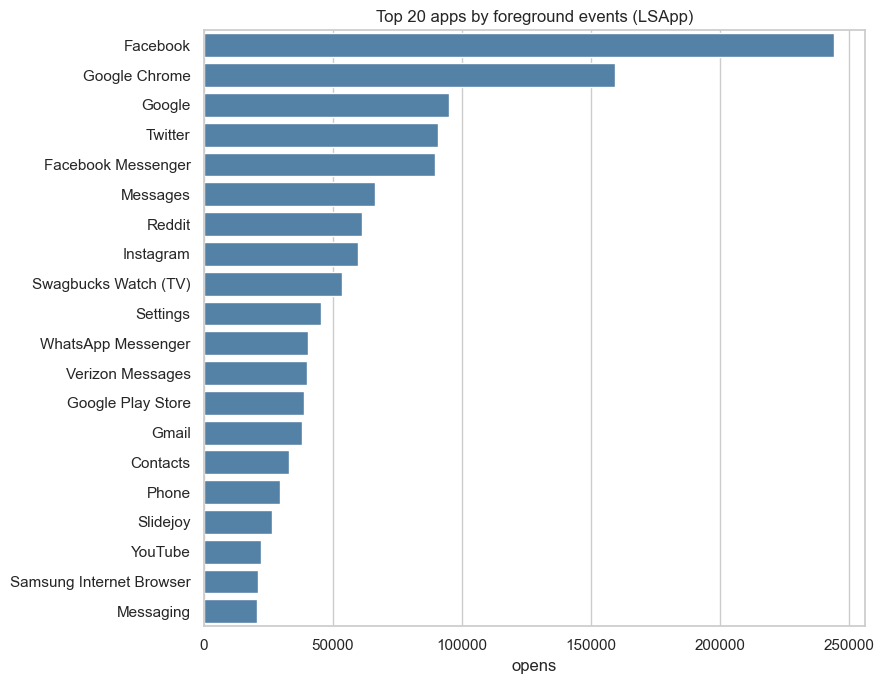

In [7]:
top20 = stats.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(y=top20.index, x=top20["opens"], ax=ax, color="steelblue")
ax.set_xlabel("opens")
ax.set_ylabel("")
ax.set_title("Top 20 apps by foreground events (LSApp)")
plt.tight_layout()

## Distribution of events per user

Sequential recommenders care about how much history each user has.

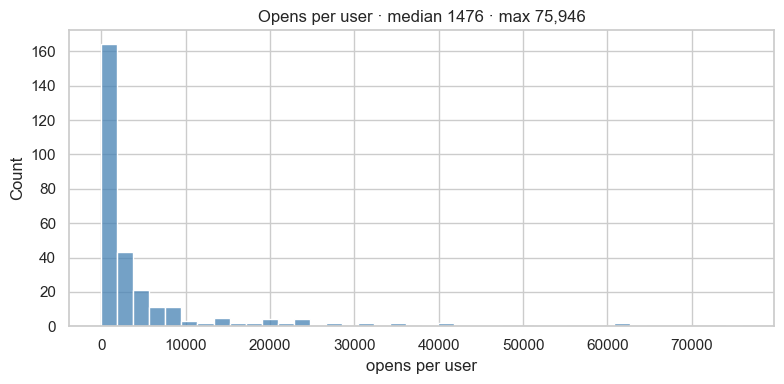

In [8]:
per_user = opened.groupby("user_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(per_user, bins=40, ax=ax, color="steelblue")
ax.set_xlabel("opens per user")
ax.set_title(f"Opens per user · median {per_user.median():.0f} · max {per_user.max():,}")
plt.tight_layout()

## Hour-of-day usage heatmap

Which apps spike at which time of day? Useful for time-aware nudging.

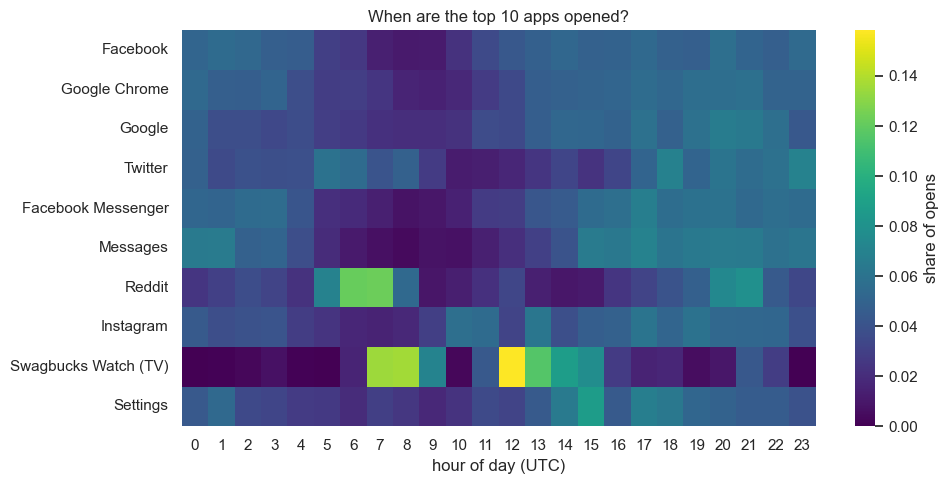

In [9]:
opened["hour"] = opened["timestamp"].dt.hour
top10_names = stats.head(10).index
heat = (
    opened[opened["app_name"].isin(top10_names)]
    .groupby(["app_name", "hour"]).size()
    .unstack(fill_value=0)
    .reindex(top10_names)
)
heat_norm = heat.div(heat.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_norm, cmap="viridis", ax=ax, cbar_kws={"label": "share of opens"})
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("")
ax.set_title("When are the top 10 apps opened?")
plt.tight_layout()

## Session-duration distribution (top apps)

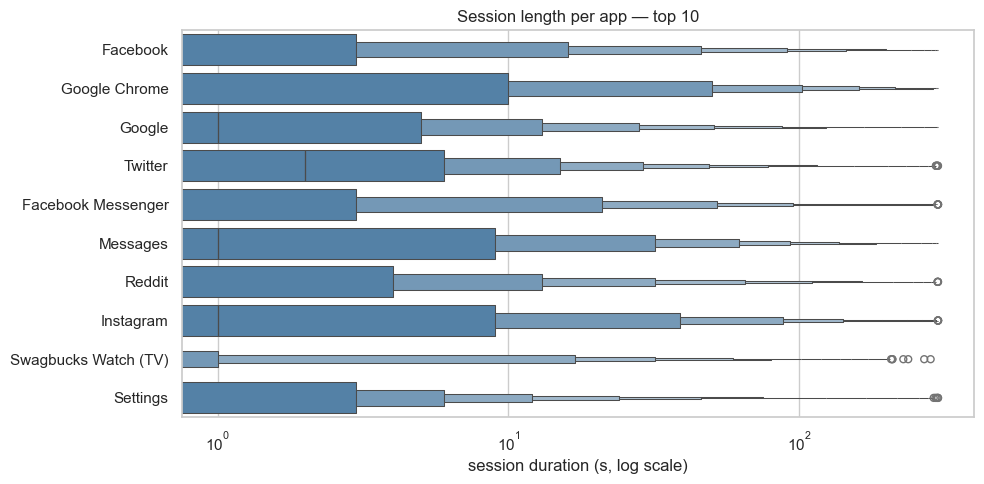

In [10]:
top10_sessions = sessions[sessions["app_name"].isin(top10_names)]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxenplot(
    data=top10_sessions, y="app_name", x="duration_s",
    order=top10_names, ax=ax, color="steelblue",
)
ax.set_xscale("log")
ax.set_xlabel("session duration (s, log scale)")
ax.set_ylabel("")
ax.set_title("Session length per app — top 10")
plt.tight_layout()

## Sequence repetition

How often is the next app the same as the current one? This is the trivial baseline
the deep models have to beat.

In [11]:
seq = opened.sort_values(["user_id", "timestamp"]).copy()
seq["prev_app"] = seq.groupby("user_id")["app_name"].shift(1)
same = (seq["app_name"] == seq["prev_app"]).mean()
print(f"P(next app = same as previous): {same:.3f}")
print(f"  → trivial 'predict same' baseline Recall@1 = {same:.3f}")

P(next app = same as previous): 0.872
  → trivial 'predict same' baseline Recall@1 = 0.872
